# Tab. — Fronthaul coordination overhead (+ bar figure)

Builds two deliverables from one `fronthaul_table` run:
1. **The table** (LaTeX `tab_fronthaul.tex` for `\input{}`, + Markdown preview).
2. **The bar figure** `fig_fronthaul.pdf` — per-AP, per-round payload as grouped
   bars at two array sizes M, showing that Centralized grows with M while
   CORDIS-Split and CORDIS-ADMM are **independent of M**.

Table renderers come from `build_tab_fronthaul.py`; **`build_bar_figure` is inlined
below as an editable cell** so you can restyle without editing the module.

Payloads are reported **per coordination round** (apples-to-apples); ADMM runs
T_ADMM rounds/solve (shown in the table's total/solve column and annotated on the
figure). Centralized is exactly linear in M, so its M_hi bar is extrapolated from the
single run; pass a measured second run if you prefer.

**Compatible experiment:** `fronthaul_table` (`kind=='table'`).

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FIG_DIR = Path.cwd()
if str(FIG_DIR) not in sys.path:
    sys.path.insert(0, str(FIG_DIR))

import build_tab_fronthaul as B   # loader + renderers (single source of truth)
from cordis.plotting import apply_paper_style, figsize, style_for, save_figure
from cordis.plotting.style import ALGORITHM_STYLE   # tweak here to restyle bars

USE_TEX = True   # set False on a node without pdflatex (figure only)
apply_paper_style()
logging.basicConfig(level=logging.INFO, format='%(levelname)-7s %(message)s')

## 1. Load the fronthaul_table run

In [2]:
RESULT_DIR = None   # e.g. 'results/exp_fronthaul_table/20260601_120000'
result, result_dir = B.load_table(RESULT_DIR, experiment='fronthaul_table')
print('run:', result_dir)
print('algorithms:', list(result.table_data.keys()))
print('metadata:', {k: result.metadata.get(k) for k in ('M','n_ue','n_targets','n_streams','admm_avg_iters')})

run: /Users/mehdi/Local-Drive/GitHub/CORDIS/results/exp_fronthaul_table/20260602_170135
algorithms: ['Centralized', 'CORDIS-Split', 'CORDIS-ADMM']
metadata: {'M': 16, 'n_ue': 4, 'n_targets': 2, 'n_streams': 6, 'admm_avg_iters': 91.95}


## 2. Operating sizes + numeric summary

`M_HI` adds the second array size for the M-independence bars. Set `M_HI = M_LO`
(the run's M) to draw a single bar per algorithm.

In [64]:
M_LO = float(result.metadata.get('M') or 0) or 1.0
M_HI = 64.0      # second array size for the M-independence bars
summary = B.collect_summary(result, M_LO, M_HI)
B._print_summary(result, summary, M_LO, M_HI)

[info] scenario   : M=16, N_UE=4, N_targets=2, |D|=6
[info] T_ADMM      : 91.95
[info] bar M values: M_lo=16, M_hi=64
algorithm       per-round@Mlo  per-round@Mhi   iters  M-indep scalable
----------------------------------------------------------------------
Centralized               320           1280       1       NO        ✗
CORDIS-Split               15             15       1      yes        ✓
CORDIS-ADMM               104            104    92.0      yes        ✓


## 3. The table — Markdown preview + LaTeX for the paper

Writes `paper/figures/tab_fronthaul.{md,tex}`. `\input{figures/tab_fronthaul.tex}`
in the paper (needs `booktabs`).

In [65]:
md_text  = B.render_markdown(result)
tex_text = B.render_latex(result)
print(md_text)
print(tex_text)

figures_dir = FIG_DIR.parents[1] / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
(figures_dir / 'tab_fronthaul.md').write_text(md_text, encoding='utf-8')
(figures_dir / 'tab_fronthaul.tex').write_text(tex_text, encoding='utf-8')
print('wrote', figures_dir / 'tab_fronthaul.md', 'and .tex')

# Fronthaul Coordination Overhead per AP

_Scenario: M=16, N_UE=4, N_targets=2, |D|=6_

_Average ADMM iterations: T_ADMM = 91.95_

| Algorithm | Data shared | Size | Real scalars / round | Iterations | Total / solve | Scales with | Scalable |
|---|---|---|---|---|---|---|---|
| Centralized | $\widehat{\mathbf{H}}_{a_t},\ \mathbf{W}_{a_t}$ | $\mathbb{C}^{M_t \times N_{\rm UE}} + \mathbb{C}^{M_t \times |\mathcal{D}|}$ | 320 | 1 | 320 | $M_t \cdot (N_{\rm UE} + |\mathcal{D}|)$ | ✗ |
| CORDIS-Split | $\{\widehat{\beta}_{a_t u}, \widetilde{g}_{a_t u}, e_{a_t u}^{(s)}\}_{u \in \mathcal{U}},\ z_{a_t}, \widetilde{q}_{a_t},\ \rho^\ast_{a_t}$ | $(3 N_{\rm UE} + 3) \times \mathbb{R}$ | 15 | 1 | 15 | $N_{\rm UE}$ | ✓ |
| CORDIS-ADMM | $\mathbf{l}_{a_t u}\ (\mathrm{up}),\ \widetilde{\boldsymbol{\Sigma}}_u\ (\mathrm{dn})$ | $2 \cdot N_{\rm UE} \cdot \mathbb{C}^{|\mathcal{D}|+1}$ per outer iter | 104 | 92.0 | 9562.8 | $N_{\rm UE} \cdot (2|\mathcal{D}| + 1)$ | ✓ |

\begin{table}[t]
\centering
\caption

## 4. `build_bar_figure` — editable copy

The **exact** function from `build_tab_fronthaul.py`, inlined so you can edit it
(colors, hatch, log scale, annotation) and re-run. Mutate `ALGORITHM_STYLE` in the
setup cell to restyle the per-algorithm bar colors without editing the body.

In [67]:
# Bind the module-level names the function body references.
from typing import Optional, Sequence   # the inlined signature uses these
PREFERRED      = B.PREFERRED
M_HI_DEFAULT   = B.M_HI_DEFAULT
_ordered_algos = B._ordered_algos
_scalars_at_M  = B._scalars_at_M
_is_m_dependent= B._is_m_dependent
logger         = logging.getLogger('tab_fronthaul.nb')

In [94]:
def build_bar_figure(result,
                     *,
                     m_lo: Optional[float] = None,
                     m_hi: Optional[float] = M_HI_DEFAULT,
                     table_hi=None,
                     preferred: Sequence[str] = PREFERRED,
                     use_tex: bool = True):
    """Grouped per-round fronthaul-payload bars at M_lo and M_hi.

    ``m_lo`` defaults to the run's M (from metadata).  ``m_hi`` adds a second
    bar per algorithm to expose M-independence; pass ``m_hi=None`` for a single
    bar per algorithm.  If ``table_hi`` (a second result's ``table_data``) is
    given, the M_hi bars use those *measured* values instead of extrapolating.

    Returns ``(fig, m_lo, m_hi)``.
    """
    import matplotlib
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from cordis.plotting import apply_paper_style, figsize, style_for

    apply_paper_style()
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False

    ANNOTATION_FONTSIZE = 8
    # Define the IEEE standard font size
    IEEE_FONT_SIZE = 8
    plt.rcParams.update({
        # Base font size (affects default text and titles)
        "font.size": IEEE_FONT_SIZE,
        # Axis labels (e.g., 'ADMM iteration', 'min-SINR [dB]')
        "axes.labelsize": IEEE_FONT_SIZE,
        # Axis tick labels (the numbers on the axes)
        "xtick.labelsize": IEEE_FONT_SIZE,
        "ytick.labelsize": IEEE_FONT_SIZE,
        # Legend font size
        "legend.fontsize": IEEE_FONT_SIZE,
        # Legend title font size (if you ever use legend titles)
        "legend.title_fontsize": IEEE_FONT_SIZE,
        # Figure titles (if you ever use fig.suptitle)
        "figure.titlesize": IEEE_FONT_SIZE,
        # Subplot titles (e.g., if you switch SET_TITLE to True)
        "axes.titlesize": IEEE_FONT_SIZE,
    })


    table = result.table_data
    md = result.metadata or {}
    if m_lo is None:
        m_lo = float(md.get("M") or 0) or 1.0
    algos = _ordered_algos(table, preferred)
    t_admm = md.get("admm_avg_iters", None)

    two_m = (m_hi is not None) and (float(m_hi) != float(m_lo))

    def _hi_value(algo, row):
        if table_hi is not None and algo in table_hi:
            return float(table_hi[algo].get("real_scalars", float("nan")))
        return _scalars_at_M(row, m_lo, m_hi)

    fig, ax = plt.subplots(figsize=figsize(width="single", aspect=3.5 / 2.6))
    x = np.arange(len(algos))
    width = 0.38 if two_m else 0.56

    def _color(name):
        c = style_for(name).get("color")
        return c or "0.5"

    lo_vals = [_scalars_at_M(table[a], m_lo, m_lo) for a in algos]
    max_ylim = 1.0
    if two_m:
        hi_vals = [_hi_value(a, table[a]) for a in algos]
        bars_lo = ax.bar(x - width / 2, lo_vals, width,
                         color=[_color(a) for a in algos], edgecolor="black",
                         linewidth=0.5, zorder=3)
        bars_hi = ax.bar(x + width / 2, hi_vals, width,
                         color=[_color(a) for a in algos], edgecolor="black",
                         linewidth=0.5, alpha=0.55, hatch="///", zorder=3)
        # M legend (shade/hatch encodes M; color encodes algorithm)
        leg = [Patch(facecolor="0.6", edgecolor="black", label=f"$M={int(m_lo)}$"),
               Patch(facecolor="0.6", edgecolor="black", alpha=0.55,
                     hatch="///", label=f"$M={int(m_hi)}$")]
        ax.legend(handles=leg, loc="best", framealpha=0.9)
        bar_groups = [(bars_lo, lo_vals), (bars_hi, hi_vals)]
        max_ylim = max(max(hi_vals), max(lo_vals))
    else:
        bars_lo = ax.bar(x, lo_vals, width,
                         color=[_color(a) for a in algos], edgecolor="black",
                         linewidth=0.5, zorder=3)
        bar_groups = [(bars_lo, lo_vals)]
        max_ylim = max(lo_vals)

    # value labels on top of each bar
    for bars, vals in bar_groups:
        for rect, v in zip(bars, vals):
            if not np.isfinite(v):
                continue
            ax.annotate(f"{int(round(v))}",
                        xy=(rect.get_x() + rect.get_width() / 2, v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=ANNOTATION_FONTSIZE)

    # annotate T_ADMM just above the ADMM group (per-round bars; ×T per solve).
    # Multiplicative offset = consistent visual gap on the log axis.
    if t_admm is not None and "CORDIS-ADMM" in algos:
        i = algos.index("CORDIS-ADMM")
        y_admm = lo_vals[i] if np.isfinite(lo_vals[i]) else 1.0
        ax.text(i*0.96, y_admm * 1.9,
                rf"$\times\,T_{{\rm ADMM}}\!\approx\!{float(t_admm):.0f}$/solve",
                ha="center", va="bottom", fontsize=ANNOTATION_FONTSIZE, color="0.3")

    ax.set_yscale("log")
    ax.set_ylim(top=max_ylim*1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(algos, rotation=0, ha="center")
    ax.set_ylabel("Real scalars / AP / round")
    # ax.set_title("Fronthaul coordination overhead")
    ax.grid(True, axis="y", which="both", alpha=0.3, zorder=0)

    fig.tight_layout()
    return fig, float(m_lo), (float(m_hi) if two_m else None)


## 5. Render the bar figure

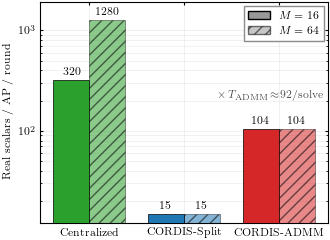

In [95]:
fig, used_m_lo, used_m_hi = build_bar_figure(
    result, m_lo=M_LO, m_hi=M_HI, use_tex=USE_TEX,
)
plt.show()

## 6. Save the bar figure to `paper/figures/`

In [97]:
out_stem = FIG_DIR.parents[1] / 'figures' / 'fig_fronthaul'
paths = save_figure(
    fig, out_stem, formats=('pdf','png'),
    metadata={
        'Figure': 'fig_fronthaul',
        'Mlo': f'{used_m_lo:g}',
        'Mhi': (f'{used_m_hi:g}' if used_m_hi else '—'),
        'TADMM': f"{result.metadata.get('admm_avg_iters', float('nan')):.2f}",
        'Run': result_dir.name,
    },
)
for p in paths:
    print('wrote', p)

wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_fronthaul.pdf
wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_fronthaul.png
